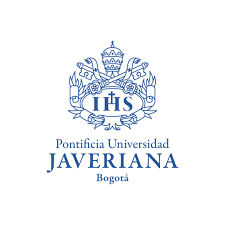
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**


Autor: Juan Felipe Góme López

Fecha de Inicio: 6/10/2026

Fecha actual: 6/10/2026


## **Apache Spark**

- Spark es un *FrameWork* para Big Data que incluye *bibliotecas* para el análisis de datos, el aprendizaje automático, el análisis de grafos y el procesamiento de datos en tiempo real. 
- Spark se presenta mucho más rápido dado que escribe los resultados/objetos intermedios en memoria principal siempre que sea posible.
- El ecosistema de Hadoop incluye un sistema de almacenamiento de archivos distribuido llamado HDFS (Hadoop Distributed File System). 
- Spark, por su parte, no incluye un sistema de almacenamiento de archivos. 
- Se puede utilizar Spark sobre HDFS, o de otras fuentes (locales o en la nube).
- Spark no es un lenguaje de programación como Python o Java. Se trata de un motor de procesamiento de datos distribuido de uso general, adecuado para su aplicación en una amplia variedad de situaciones. Resulta especialmente útil para el procesamiento de big data, tanto a gran escala como a alta velocidad.
- Los desarrolladores de aplicaciones y los científicos de datos suelen incorporar Spark en sus aplicaciones para consultar, analizar y transformar datos rápidamente y a gran escala.
- Algunas de las tareas que se asocian con mayor frecuencia a Spark incluyen:
        – Trabajos por lotes de ETL y SQL en grandes conjuntos de datos (a menudo de terabytes de tamaño).
        – Procesamiento de datos en streaming procedentes de dispositivos y nodos de IoT, datos de diversos sensores, sistemas financieros y transaccionales de todo tipo.
        – Tareas de aprendizaje automático para aplicaciones de comercio electrónico o de TI.

- En esencia, Spark se basa en el marco Hadoop/HDFS para gestionar archivos distribuidos. Se implementa principalmente con Scala, una variante del lenguaje funcional de Java.
- Existen bibliotecas desarrolladas para el análisis de consultas de tipo SQL, el aprendizaje automático distribuido, el cálculo de grafos a gran escala y el procesamiento de datos en streaming, que se pueden acceder desde SPARK.
- Spark admite múltiples lenguajes de programación en forma de bibliotecas de interfaz fáciles de usar: Java, Python, Scala y R.

## **Funcionamiento**

- La idea básica del procesamiento distribuido consiste en dividir los bloques de datos en pequeñas partes manejables (lo que incluye ciertos procesos de filtrado y ordenación), acercar el cálculo a los datos —es decir, utilizar pequeños nodos de un gran clúster para tareas específicas— y, a continuación, volver a combinarlos.

- La parte de división se denomina acción «Map» y la recombinación se denomina acción «Reduce». Juntas, conforman el famoso paradigma «MapReduce», que fue introducido por Google alrededor de 2004.

- Por ejemplo, si un archivo tiene 100 registros que procesar, 100 mappers pueden ejecutarse a la vez para procesar un registro cada uno. O tal vez 50 mapeadores pueden ejecutarse juntos para procesar dos registros cada uno. Una vez que todos los mapeadores han completado el procesamiento, el marco baraja y ordena los resultados antes de pasarlos a los reductores. Un reductor no puede iniciarse mientras un mapeador aún está en curso.

- Todos los valores de salida del mapeo que tienen la misma clave se asignan a un único reductor, que a continuación agrega los valores para esa clave.

## **RDD**

- RDD son las siglas de «Resilient Distributed Dataset» (conjunto de datos distribuido y resistente); se trata de elementos que se ejecutan y operan en varios nodos para realizar un procesamiento paralelo en un clúster.
- Los RDD son elementos inmutables, lo que significa que, una vez creado un RDD, no se puede modificar.
- Los RDD también son tolerantes a fallos, por lo que, en caso de producirse algún fallo, se recuperan automáticamente.
- Se pueden aplicar múltiples operaciones a estos RDD para llevar a cabo una tarea determinada.
- Para aplicar operaciones a estos RDD, hay dos formas:
        –  Transformación: son las operaciones que se aplican a un RDD para crear un nuevo RDD. Filter, groupBy y map son ejemplos de transformaciones.
        – Acción: son las operaciones que se aplican a un RDD y que indican a Spark que realice el cálculo y envíe el resultado al controlador.


## **Objetivos**

- 1.- Importar bibliotecas necesarias
- 2.- Crear una sesión con SPARK
- 3.- Interactuar con RDD
- 4.- Operaciones sobre los RDD's
- 5.- Creación de Funciones Definidas por el Usuario (UDF)
- 6.- Interacción con Hadoop HDFS
- 7.- Carga de CSV desde Hadoop HDFS hacia Spark
- 8.- Aplicaciones de funciones varias: map, parallelize y lambda
- 9.- Objetos DataFrame en Spark
    * Creación de DataFrame manualmente
    * Lectura de DF
    * Escritura de DF
    * Validar DF
    * Búsquedas en DF
    * Selección de funcionalidad sobre un DF
    * Filtrar DF
    * Dividir DF

- 10.- Introducing SQL in PySpark

### **1.- Importar Bibliotecas**

In [1]:
###-->

import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###-->
import findspark
findspark.init("/mnt/sda1/Cluster/Spark")
from pylab import *
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

### **2.- Creación de Sesión de Trabajo SPARK y Contexto SPARK**

In [2]:
###--> Creación de sesión SPARK
"""
SparkConf es la clase que se utiliza para configurar una aplicación de Apache Spark. Permite establecer diversos parámetros en forma de 
pares clave valor como por ejemplo el nombre de la aplicación, el modo de ejecución o la cantidad de memoria antes de arrancar el contexto de Spark.
"""
configura = SparkConf()

###--> Se crea la configuración
#Aqui se utiliza el metodo llamado setAppName de la clase SparkConf y se le envía como parámetro "Spark_GomezLopez_00" el cual es el nombre de la aplicacion
configura.setAppName("Spark_GomezLopez_00")

###--> Se crea la SESIÓN en función de la configuración (Spark+Apellido del autor)
"""
- SparkSession.builder lanza el proceso para construir una SparkSession.
- config(conf=configura) agrega a la sesión la configuración realizada en la variable "configura".
- `getOrCreate()` either retrieves an existing `SparkSession` or creates a new one.
"""
sparkGomezLopez = SparkSession.builder.config(conf=configura).getOrCreate()

"""
SQLContext es el punto de entrada a SparkSQL el cual es un modulo de Spark para procesamiento de datos estructurado. 
Una vez SQLContext Once es inicializado, el usuario puede usarlo para ejecutar varias sentencias SQL sobre Datasets y Dataframes.
"""
SQLContext(sparkContext=sparkGomezLopez.sparkContext, sparkSession=sparkGomezLopez)

"""
Se crea el sparkContext el cual es usado por el proceso Driver con el objetivo de establecer un canal de comunicacion con el cluster y los resource managers
para correr y ejecutar jobs
"""
sparkGomezLopezContext = sparkGomezLopez.sparkContext.getOrCreate()

###--> Creamos un print para que sirva como log con la intención se saber si la sesion de Spark y os demas procesos necesarios se inicializaron con éxito
print("\nSesion creada: Laboratorio 01\n")

###-->
sparkGomezLopez

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/08 07:13:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/08 07:13:17 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/10/08 07:13:17 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/10/08 07:13:17 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.



Sesion creada: Laboratorio 01



### **3.- Interacción sobre RDD de Spark**

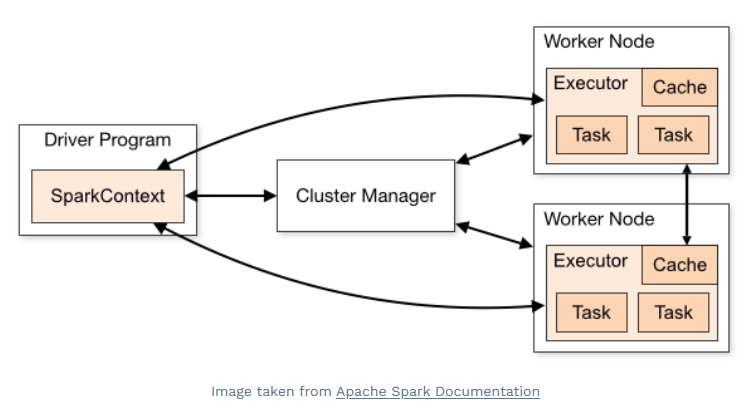

Acá podemos ver un diagrama de despliegue de cómo se ve organizado el cluster y qué procesos se comunican entre sí. El mas importante para anotar aquí es el SparkContext que es usado por el Driver Program

In [3]:
###--> 3.1.- Creación de un RDD vacio
"""
Un RDD (resilient distributed dataframe) es la API principal y más profundamente es una coleccion de datos inmutable particionada en los nodos del cluster 
que pueden ser operados en paralelo con sentencias que el usuario puede ejecutar desde cuadernos/notebooks.

Aqui se crea un RDD vacío que no contiene elementos ni particiones a lo largo del cluster
"""
rdd = sparkGomezLopezContext.emptyRDD()
rdd.isEmpty()

True

In [4]:
###-->En este caso se está asignando a la variable "a" un rdd que está vacio y una colección de python que será paralelizable

a = sparkGomezLopezContext.parallelize([])
a.isEmpty()

True

In [5]:
###--> 3.3.- Se crea un RDD con particiones manualmente
#En este caso se crea un RDD a partir de la colección de datos de origen. En este caso particular, es una lista de Python que contiene tres elementos, un booleano, una lista y una tupla
mixRDD = sparkGomezLopezContext.parallelize([True, [11,22,33,44,55], (10,20,30,40,50)], 3)
mixRDD.collect()

[True, [11, 22, 33, 44, 55], (10, 20, 30, 40, 50)]

In [6]:
###--> 3.4.- Se revisa el número de particiones
#El numero de particiones que está utilizando el cluster para distribuir el RDD 
mixRDD.getNumPartitions()

3

In [7]:
###--> 3.5.- Se recopila los datos con particiones
#.glom().collect() recopila los datos que estan en cada particion y los convierte a una lista, después junta todas estas listas en una lista, lo cual genera una lista anidada.
mixRDD.glom().collect()

[[True], [[11, 22, 33, 44, 55]], [(10, 20, 30, 40, 50)]]

In [8]:
###-->En esta sentencia se asigna el nombre deseado al mixRDD el cual es el RDD

mixRDD.setName('Mi_RDD')

Mi_RDD ParallelCollectionRDD[4] at readRDDFromFile at PythonRDD.scala:289

In [9]:
###--> Usando Rangos para crear RDD

a= sparkGomezLopezContext.parallelize(range(1,4000), 4)
print(a.getNumPartitions()) #muestra el numero de particiones
print("\n")
print(a.glom().take(1)) ###--> toma lo que tiene la primera particion
print("\n")
print(a.glom().max()) #calcula el maximo de las particiones
print("\n")
print(a.glom().min()) #calcula el minimo de las particiones
print("\n")

4


[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 22

In [10]:
###--> Se ordenan y re-reparten RDD

###--> Uso de función lambda o función anónima para ordenar

b = sparkGomezLopezContext.parallelize([12,21,23,43,1,22,11,45,56])
b.takeOrdered(4, key=lambda x: -x)

[56, 45, 43, 23]

In [11]:
###--> Coalescence, reparticiones y debug (DAG)
#Se distribuye la coleccion e python en 5 particiones
c = sparkGomezLopezContext.parallelize(range(1,1000), 5)
###--> 
c.getNumPartitions()

5

In [12]:
###-->repartition siempre busca hacer el shuffle con los datos 
d = c.repartition(7)
d.getNumPartitions()

###-->Aqui variamos al numero de particiones
w = c.repartition(4)
w.getNumPartitions()

4

In [13]:
###-->En cambio coalesce siempre busca minimizarr el shuffle y ejecutar lo que mas se pueda de manera local
w.coalesce(6)
w.getNumPartitions()

###--> cmbiamos el numero de particiones por dos
w.coalesce(2)
w.getNumPartitions()

4

Referencia: <a href="https://www.databricks.com/blog/2015/06/22/understanding-your-spark-application-through-visualization.html">DAG en DataBricks</a>

In [14]:
###-->Muestra la descripcion y etado del RDD para tener observabilidad del RDD.

w.toDebugString()

b'(4) MapPartitionsRDD[22] at coalesce at NativeMethodAccessorImpl.java:0 []\n |  CoalescedRDD[21] at coalesce at NativeMethodAccessorImpl.java:0 []\n |  ShuffledRDD[20] at coalesce at NativeMethodAccessorImpl.java:0 []\n +-(5) MapPartitionsRDD[19] at coalesce at NativeMethodAccessorImpl.java:0 []\n    |  PythonRDD[18] at RDD at PythonRDD.scala:53 []\n    |  ParallelCollectionRDD[12] at readRDDFromFile at PythonRDD.scala:289 []'

### - **4.- Operaciones sobre los RDD's**

- #### **Transformación**

* Las transformaciones son un tipo de operaciones que transforman los datos de un RDD de una forma a otra. Al aplicar esta operación a cualquier RDD, se obtiene un nuevo RDD con los datos transformados (los RDD en Spark son inmutables). Operaciones como map, filter y flatMap son transformaciones.

* Cuando se aplica la transformación a cualquier RDD, la operación no se ejecuta de inmediato. Se creará un DAG (grafo acíclico dirigido) utilizando la operación aplicada, el RDD de origen y la función utilizada para la transformación. Y seguirá construyendo este grafo utilizando las referencias hasta que se aplique cualquier operación de acción al último RDD de la fila. Por eso las transformaciones en Spark son *perezosas*. Spark dispone de ciertas operaciones que se pueden realizar sobre un RDD. Una operación es un método que se puede aplicar a un RDD para llevar a cabo una tarea determinada. Los RDD admiten dos tipos de operaciones: acciones y transformaciones. Una **operación** puede ser algo tan sencillo como ordenar, filtrar y resumir datos. Las transformaciones y acciones se destacan a continuación:

    - **Transformación «Narrow»:** todos los elementos necesarios para calcular los registros de una sola partición se encuentran en esa misma partición del RDD padre. Se utiliza un subconjunto limitado de la partición para calcular el resultado. Las transformaciones «Narrow» son el resultado de map() y filter().
 
    - **Transformación «Warrow»:** todos los elementos necesarios para calcular los registros de una sola partición pueden encontrarse en muchas particiones del RDD padre. La partición puede encontrarse en muchas particiones del RDD padre. Las transformaciones amplias son el resultado de groupbyKey y reducebyKey.
 
- #### **Acciones**
  * Las transformaciones crean RDD a partir de otras, pero cuando queremos trabajar con el conjunto de datos real, es en ese momento cuando se ejecuta una acción. Cuando la acción se activa tras el resultado, no se crea un nuevo RDD como ocurre con las transformaciones. Por lo tanto, las acciones son operaciones de RDD que devuelven valores que no son RDD. Los valores de las acciones se almacenan en los controladores o en el sistema de almacenamiento externo. Esto pone en práctica la «pereza» de los RDD.
  * Los controladores de Spark y el sistema de almacenamiento externo almacenan el valor de la acción. Esto pone en marcha la pereza de los RDD. Una acción es una de las formas de enviar datos desde el ejecutor al controlador. Los ejecutores son agentes responsables de ejecutar una tarea. Por su parte, el controlador es un proceso de la JVM que coordina a los trabajadores y la ejecución de la tarea.

In [15]:
###--> paralelizamos esta coleccion
red01 = sparkGomezLopezContext.parallelize([1,9,5,6,7,8])
###--> Se ejecuta por cada parametro una suma enre a y b
red01.reduce(lambda a,b:a+b)

36

In [16]:
###--> En este caso se multiplica
red01.reduce(lambda a,b:a*b)

15120

### - **5.- Creación de Funciones Definidas por el Usuario (UDF)**

In [17]:
###--> Se crea una lista con palabras
palabras = ['Que', 'tal', 'estas', 'hola', 'hey', 'hora']
###--> Se paraleliza la coleccion mediante el RDD 
palabraRDD = sparkGomezLopezContext.parallelize(palabras)
###--> Devuelve los registros que tenga el RDD
palabraRDD.collect()

['Que', 'tal', 'estas', 'hola', 'hey', 'hora']

In [18]:
###--Se crea una funcion par saber si una cadena empieza con h
def inicio_h(palabras):
    return palabras[0].lower().startswith('h')

In [19]:
###--> Se aplica la UDF como filtro
palabraRDD.filter(inicio_h).collect() ###--> Se usa la sentencia filter para encontrar cuales cadena cumplen la condicion

['hola', 'hey', 'hora']

In [20]:
###-->Se crea funcion para cpvertir a mayuscula
def mayuscula(p):
    return p.upper()

In [21]:
###--> se define la lista de palabrs a convertir
lista0 = ['cómputo', 'mayor', 'menor']
###--> Se paraleliza on el RDD
lista1 = sparkGomezLopezContext.parallelize(lista0)
###--> Se aplica map el cual aplica la funcion a cada elemento de la lista
mapeo0 = lista1.map(mayuscula)
###--> Se obtiene el registro en formato row
mapeo0.collect()

['CÓMPUTO', 'MAYOR', 'MENOR']

In [22]:
###-->Ahora se realiza el mapeo pero usando una funcion anonima
mapeo1 = lista1.map(lambda k:k.upper())
###--> Se obtiene el resultado
mapeo1.collect()

['CÓMPUTO', 'MAYOR', 'MENOR']

### - **6.- Interacción con Sistema de Ficheros Distribuidos HADOOP HDFS**

In [23]:
###--> Lista el contenido del directorio /
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /

Found 6 items
drwxr-xr-x   - sistemas  supergroup          0 2025-10-31 15:50 /DistriFlipa
drwxr-xr-x   - sistemas  supergroup          0 2026-04-28 08:17 /csv
drwxr-xr-x   - sistemas  supergroup          0 2025-09-02 13:23 /json
drwxr-xr-x   - sistemas  supergroup          0 2025-09-02 16:56 /parquet
drwxrwxr-x+  - userpm025 supergroup          0 2025-10-25 17:51 /pm25
drwxr-xr-x   - usuario22 usuario22           0 2026-04-15 15:19 /user22


In [24]:
###-->  lista los archivos y directorios que se encuentran dentro de la ruta /csv/titanic en el Sistema de Archivos Distribuidos de Hadoop
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv/titanic

Found 3 items
-rw-r--r--   2 sistemas supergroup      28629 2026-04-23 15:56 /csv/titanic/test.csv
-rw-r--r--   2 sistemas supergroup      88432 2026-04-23 15:48 /csv/titanic/titanic_com.csv
-rw-r--r--   2 sistemas supergroup      61194 2026-04-23 15:56 /csv/titanic/train.csv


In [25]:
###--> Carga el fichero test.csv desde HDFS
fichero = sparkGomezLopezContext.textFile("hdfs://10.195.34.34:9000/csv/titanic/test.csv")
###--> Presenta resumen del contenido en el objeto "fichero"
fichero.collect()

['PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked',
 '892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,,Q',
 '893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7,,S',
 '894,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,9.6875,,Q',
 '895,3,"Wirz, Mr. Albert",male,27,0,0,315154,8.6625,,S',
 '896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,1,3101298,12.2875,,S',
 '897,3,"Svensson, Mr. Johan Cervin",male,14,0,0,7538,9.225,,S',
 '898,3,"Connolly, Miss. Kate",female,30,0,0,330972,7.6292,,Q',
 '899,2,"Caldwell, Mr. Albert Francis",male,26,1,1,248738,29,,S',
 '900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18,0,0,2657,7.2292,,C',
 '901,3,"Davies, Mr. John Samuel",male,21,2,0,A/4 48871,24.15,,S',
 '902,3,"Ilieff, Mr. Ylio",male,,0,0,349220,7.8958,,S',
 '903,1,"Jones, Mr. Charles Cresson",male,46,0,0,694,26,,S',
 '904,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23,1,0,21228,82.2667,B45,S',
 '905,2,"Howard, Mr. Benj

In [26]:
###---> Creación de Flat Maps
###--->separa cada celda usando una coma como separador
###--->Transforma cada elemento o palabra en un par clave valoe (palabra, 1).
###--->Toma cada linea del archivo y la divide usando una coma como separador y despues Agrupa todos los elementos que tienen la misma clave y combina sus valores.
fichero.flatMap(lambda x:x.split(",")).map(lambda x: (x,1)).reduceByKey(lambda a,b:a+ b).collect()

[('PassengerId', 1),
 ('Pclass', 1),
 ('SibSp', 1),
 ('Parch', 1),
 ('Fare', 1),
 ('Cabin', 1),
 ('3', 226),
 ('male', 266),
 ('0', 609),
 ('', 414),
 ('Q', 46),
 ('"Wilkes', 1),
 ('female', 152),
 ('7', 3),
 ('S', 270),
 ('"Myles', 1),
 (' Mr. Thomas Francis"', 2),
 ('62', 1),
 ('240276', 1),
 (' Mr. Albert"', 1),
 ('896', 1),
 (' Mrs. Alexander (Helga E Lindqvist)"', 1),
 ('22', 16),
 ('3101298', 1),
 ('12.2875', 1),
 ('"Svensson', 1),
 ('14', 2),
 ('9.225', 1),
 ('"Connolly', 1),
 ('330972', 1),
 ('"Caldwell', 1),
 ('26', 31),
 ('29', 11),
 ('900', 1),
 ('18', 14),
 ('2657', 1),
 ('7.2292', 9),
 ('901', 1),
 (' Mr. John Samuel"', 1),
 ('21', 25),
 ('24.15', 1),
 ('"Ilieff', 1),
 ('"Jones', 1),
 ('694', 1),
 ('82.2667', 2),
 ('B45', 2),
 ('905', 1),
 (' Mr. Benjamin"', 1),
 ('906', 1),
 ('"Chaffee', 1),
 ('W.E.P. 5734', 1),
 ('61.175', 1),
 ('907', 1),
 ('"del Carlo', 1),
 (' Mrs. Sebastiano (Argenia Genovesi)"', 1),
 ('24', 17),
 ('SC/PARIS 2167', 1),
 ('27.7208', 6),
 ('908', 1),
 

### **- 7.- Aplicaciones de funciones varias: map, parallelize y lambda**

In [27]:
###---> Listas y replicación
###--->Crea primero una coleccion y le aplica la funcion de triplicar el valor y que cada posicion tenga una lista con tres veces el mismo elemento
sparkGomezLopezContext.parallelize([4,5,6,7]).map(lambda x:[x,x,x]).collect()

[[4, 4, 4], [5, 5, 5], [6, 6, 6], [7, 7, 7]]

In [28]:
###---> Crea la coleccion y primero triplica el registor y lo guarda en una lista, despues multiplica ese registro tres veces y despues le suma 5 al primer valor de la lista de tres elementos
sparkGomezLopezContext.parallelize([5,6,7,8]).map(lambda x:[[x,x,x],[x*x*x],[x+5]]).collect()

[[[5, 5, 5], [125], [10]],
 [[6, 6, 6], [216], [11]],
 [[7, 7, 7], [343], [12]],
 [[8, 8, 8], [512], [13]]]

In [29]:
###--->Se paraleliza la lista de frutas con el rdd
entradaFruta = sparkGomezLopezContext.parallelize(["manzana", "banana", "piña", "limón"])
###---> Se obtiene el contenido del rdd y se aplica un count
print(f"{entradaFruta.collect()} \n La cantidad de frutas = {entradaFruta.count()}")

['manzana', 'banana', 'piña', 'limón'] 
 La cantidad de frutas = 4


In [30]:
###---> Creación de un diccionario según la cantidad de valores que se repiten
dicPorCantidad = sparkGomezLopezContext.parallelize([2,2,2,4,4,4,4,6,6,6,6,6,7]).countByValue()
dicPorCantidad

defaultdict(int, {2: 3, 4: 4, 6: 5, 7: 1})

### **- 8.- Carga Fichero de texto desde HDFS**

In [31]:
###--> Carga el fichero train.csv desde HDFS
train = sparkGomezLopezContext.textFile("hdfs://10.195.34.34:9000/csv/titanic/train.csv",4)
###--> Presenta resumen del contenido en el objeto "train"
train.collect()

['PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked',
 '1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S',
 '2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C',
 '3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S',
 '4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S',
 '5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S',
 '6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q',
 '7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S',
 '8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S',
 '9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S',
 '10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C',
 '11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S',
 '12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S',
 '

In [32]:
###---> Separa cada celda por coma y esto lo agrega a caa posicion de la lista
funcJ = train.map(lambda x:x.split(","))
###---> Obtiene el resultado en formato de row y lo filtra solo por la primera posición
funcJ.collect()[0]

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [33]:
###---> Se obtiene la segunda fila del resultado collect
funcJ.collect()[1]

['1',
 '0',
 '3',
 '"Braund',
 ' Mr. Owen Harris"',
 'male',
 '22',
 '1',
 '0',
 'A/5 21171',
 '7.25',
 '',
 'S']

In [34]:
###--->
funcF = funcJ.map(lambda field:(field[5], field[1]))
###--->
funcF.collect()[0:2]

[('Age', 'Survived'), ('male', '0')]

### **- 9.- Objetos DataFrame en Spark**
    * Creación de DataFrame manualmente
    * Lectura de DF
    * Escritura de DF
    * Validar DF
    * Búsquedas en DF
    * Selección de funcionalidad sobre un DF
    * Filtrar DF
    * Dividir DF

In [35]:
###--->Se crea una lista de tuplas, cada tupla contiene una comida y su precio correspondiente, despues se pasa esto a un objeto de tipo dataframe
menu = [('Pasta',100),('Pizza',200),('Noodles',50),('Burger',199),('Dosa',10000),('Bread',1)]
df = sparkGomezLopez.createDataFrame(menu,['Comida','Precio'])
df.show()

+-------+------+
| Comida|Precio|
+-------+------+
|  Pasta|   100|
|  Pizza|   200|
|Noodles|    50|
| Burger|   199|
|   Dosa| 10000|
|  Bread|     1|
+-------+------+



In [36]:
###---> Listamos los archivos que se encuentran en el directorio 
!/mnt/sda1/Cluster/Hadoop/bin/hdfs dfs -ls /csv/

Found 11 items
-rw-r--r--   2 sistemas supergroup     977501 2026-03-10 15:27 /csv/CustomerChurn.csv
-rw-r--r--   2 sistemas supergroup      40868 2025-07-07 15:41 /csv/Fortune500USCompanies.csv
drwxr-xr-x   - sistemas supergroup          0 2025-10-16 14:17 /csv/auxiliar
-rw-r--r--   2 sistemas supergroup    4610348 2026-04-28 08:17 /csv/bank-full.csv
-rw-r--r--   2 sistemas supergroup      34635 2025-09-02 13:22 /csv/jugadores.csv
-rw-r--r--   2 sistemas supergroup    1082023 2025-09-02 13:22 /csv/resultados_futbol.csv
-rw-r--r--   2 sistemas supergroup     316971 2025-06-10 09:11 /csv/stroke_pyspark.csv
drwxr-xr-x   - sistemas supergroup          0 2025-06-18 15:36 /csv/taxi
drwxr-xr-x   - sistemas supergroup          0 2026-04-23 15:56 /csv/titanic
-rw-r--r--   2 sistemas supergroup      48036 2025-06-12 14:31 /csv/waterquality.csv
-rw-r--r--   2 sistemas supergroup      84199 2026-04-23 17:11 /csv/winequality-red.csv


In [37]:
###--->Se carga el archivo winequality-red.csv el cual delimita las columnas por ; e incluye los header.
dfWQ00 = sparkGomezLopez.read.format("csv").option("header", "true").option("delimiter", ";").load("hdfs://10.195.34.34:9000/csv/winequality-red.csv")
###---> La presentación del dataframe: "recomendación de decir cuantos registros se van a mostrar"
dfWQ00.show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|          0|           1.9|    0.076|                 11|                  34| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|          0|           2.6|    0.098|                 25|                  67| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|                 15|                  54|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|                 17|           

In [38]:

####--->e obtienen las features del dataframe obtenido en la celda superior
dfWQ00.columns

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [39]:

####---> Se utiliza la funcion printSchema para poder mira cuales son los tipos de datos de las columnas y su nulabilidad
dfWQ00.printSchema()

root
 |-- fixed acidity: string (nullable = true)
 |-- volatile acidity: string (nullable = true)
 |-- citric acid: string (nullable = true)
 |-- residual sugar: string (nullable = true)
 |-- chlorides: string (nullable = true)
 |-- free sulfur dioxide: string (nullable = true)
 |-- total sulfur dioxide: string (nullable = true)
 |-- density: string (nullable = true)
 |-- pH: string (nullable = true)
 |-- sulphates: string (nullable = true)
 |-- alcohol: string (nullable = true)
 |-- quality: string (nullable = true)



In [40]:
###--> Casting de tipo de datos
###--> Se recomienda cambio de versión, la versión anterior tiene los valores originales

dfWQ01 = dfWQ00.withColumn('fixed acidity', dfWQ00['fixed acidity'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('volatile acidity', dfWQ01['volatile acidity'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('citric acid', dfWQ01['citric acid'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('residual sugar', dfWQ01['residual sugar'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('chlorides', dfWQ01['chlorides'].cast(FloatType()))
dfWQ01 = dfWQ01.withColumn('free sulfur dioxide', dfWQ01['free sulfur dioxide'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('total sulfur dioxide', dfWQ01['total sulfur dioxide'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('density', dfWQ01['density'].cast(FloatType()))
dfWQ01 = dfWQ01.withColumn('pH', dfWQ01['pH'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('sulphates', dfWQ01['sulphates'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('alcohol', dfWQ01['alcohol'].cast(DoubleType()))
dfWQ01 = dfWQ01.withColumn('quality', dfWQ01['quality'].cast(IntegerType()))

###--> Como norma se verifica si los cambios son realizados de forma correcta
dfWQ01.dtypes

[('fixed acidity', 'double'),
 ('volatile acidity', 'double'),
 ('citric acid', 'double'),
 ('residual sugar', 'double'),
 ('chlorides', 'float'),
 ('free sulfur dioxide', 'double'),
 ('total sulfur dioxide', 'double'),
 ('density', 'float'),
 ('pH', 'double'),
 ('sulphates', 'double'),
 ('alcohol', 'double'),
 ('quality', 'int')]

In [41]:
####--> Se presenta las estadísticas de los datos
####--->Para cada columna se imprimiran sus datos estadístico descriptivos
for valor in dfWQ01.columns: 
  dfWQ01.describe([valor]).show()

+-------+------------------+
|summary|     fixed acidity|
+-------+------------------+
|  count|              1599|
|   mean| 8.319637273295838|
| stddev|1.7410963181276948|
|    min|               4.6|
|    max|              15.9|
+-------+------------------+

+-------+-------------------+
|summary|   volatile acidity|
+-------+-------------------+
|  count|               1599|
|   mean| 0.5278205128205131|
| stddev|0.17905970415353525|
|    min|               0.12|
|    max|               1.58|
+-------+-------------------+

+-------+-------------------+
|summary|        citric acid|
+-------+-------------------+
|  count|               1599|
|   mean| 0.2709756097560964|
| stddev|0.19480113740531824|
|    min|                0.0|
|    max|                1.0|
+-------+-------------------+

+-------+------------------+
|summary|    residual sugar|
+-------+------------------+
|  count|              1599|
|   mean|2.5388055034396517|
| stddev|  1.40992805950728|
|    min|             

In [42]:
####--> Funcionalidades sobre DF
####--> seleccion de la columna fixed acidity
####--> seleccion de la columna sulphates
####--> seleccion de la columna pH
#Se muestran los 5 primeros registros
dfWQ01.select(['fixed acidity','sulphates','pH']).show(5)

+-------------+---------+----+
|fixed acidity|sulphates|  pH|
+-------------+---------+----+
|          7.4|     0.56|3.51|
|          7.8|     0.68| 3.2|
|          7.8|     0.65|3.26|
|         11.2|     0.58|3.16|
|          7.4|     0.56|3.51|
+-------------+---------+----+
only showing top 5 rows



In [43]:
####-->Se seleccionan las columnas que estan en la coleccion y despues se ordena por la columna sulphates

dfWQ01.select(['fixed acidity','sulphates','pH','quality']).orderBy('sulphates').show(10)

+-------------+---------+----+-------+
|fixed acidity|sulphates|  pH|quality|
+-------------+---------+----+-------+
|          7.9|     0.33|3.36|      4|
|          8.0|     0.37|3.22|      5|
|          6.6|     0.37|3.33|      4|
|          6.7|     0.39|3.26|      7|
|          7.2|     0.39|3.41|      5|
|          7.2|     0.39|3.41|      5|
|          6.7|     0.39|3.26|      7|
|          7.2|     0.39|3.34|      5|
|          7.2|     0.39|3.34|      5|
|          7.1|      0.4|3.39|      6|
+-------------+---------+----+-------+
only showing top 10 rows



In [44]:
####-->Se seleccionan las columnas que estan en la coleccion y despues se ordena por la columna sulphates pero en orden descendente
dfWQ01.select(['fixed acidity','sulphates','pH','quality']).orderBy(dfWQ01['sulphates'].desc()).show(6)

+-------------+---------+----+-------+
|fixed acidity|sulphates|  pH|quality|
+-------------+---------+----+-------+
|          9.2|      2.0|2.74|      4|
|          8.6|     1.98|2.93|      5|
|          8.6|     1.95|2.93|      6|
|          8.6|     1.95|2.93|      6|
|          7.1|     1.62|2.94|      5|
|          8.9|     1.61|3.04|      6|
+-------------+---------+----+-------+
only showing top 6 rows



In [45]:
####---> Lista de Valores nulos o imposibles
dfWQ01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in dfWQ01.columns]).show()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|            0|               0|          0|             0|        0|                  0|                   0|      0|  0|        0|      0|      0|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+



In [46]:
####---> Slicing
####---> Se cuenta la cantidad de registroa iniciales
####---> Se cuenta la cantidad de features iiciales
print(f"Cantidad de registros iniciales: {dfWQ01.count()}")
print(f"Cantidad de columnas iniciales: {len(dfWQ01.columns)}")

####---> Se delimita el dataframe en solo 100 registros
dfWQ02 = dfWQ01.limit(100)
print(f"Registros del nuevo dfWQ02: {dfWQ02.count()}")

####---> La lista de columnas se delimita por las tres primeras
cols_lista = dfWQ01.columns[0:3]
####--->Se imprime para verificar
dfWQ03 = dfWQ01.select(cols_lista)
print(f"Cantidad de columnas en dfWQ03: {len(dfWQ03.columns)}")
####--->Se imprime la lista inicial
dfWQ03.columns

Cantidad de registros iniciales: 1599
Cantidad de columnas iniciales: 12
Registros del nuevo dfWQ02: 100
Cantidad de columnas en dfWQ03: 3


['fixed acidity', 'volatile acidity', 'citric acid']

In [47]:
###---> Aplicar filtro
###--->de las oclumnas en la lista 'fixed acidity','sulphates','pH', 'quality' donde los registros de la columna ph contenga el caracter 5
###---> Muestra los tres primeros registros que cumplen con la condicion
dfWQ01.select('fixed acidity','sulphates','pH', 'quality').where(dfWQ01.pH.like("%5%")).show(10, False)

+-------------+---------+----+-------+
|fixed acidity|sulphates|pH  |quality|
+-------------+---------+----+-------+
|7.4          |0.56     |3.51|5      |
|7.4          |0.56     |3.51|5      |
|7.4          |0.56     |3.51|5      |
|7.5          |0.8      |3.35|5      |
|7.5          |0.8      |3.35|5      |
|5.6          |0.52     |3.58|5      |
|7.6          |0.65     |3.52|5      |
|6.7          |0.54     |3.35|5      |
|6.9          |0.52     |3.45|6      |
|5.7          |0.48     |3.5 |4      |
+-------------+---------+----+-------+
only showing top 10 rows



In [48]:
###---> Aplicar filtro
###--->Se aplica un filtro para solo tener en cuenta registros con el ph mayor a 3
###--->Se aplica un filtro para solo tener en cuenta los sulfatos menores a 0.6
# Se filtran los registros que cumplna ambas condiciones
#Se muestran los 10 primeros registros del resultado del filtro
dfWQ01.filter("pH>3 and sulphates<0.6").show(10)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|                60.0|  0.998|3.16|     0.58|    9.8|      6|
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|            0.66|        0.0|           1.8|    0.075|               13.0|           

In [49]:
###---> Aplicar filtro
###--->Se aplica un filtro para solo tener en cuenta registros con el ph mayor a 3
###--->Se aplica un filtro para solo tener en cuenta los sulfatos menores a 0.6
# Se filtran los registros que cumplan alguna de las dos condiciones
dfWQ01.filter("pH>3 or sulphates<0.6").show(10)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

In [50]:
###---> Aplicar filtro
###--->Se aplica un filtro para solo tener en cuenta registros con el ph mayor a 3
###--->Se aplica un filtro para solo tener en cuenta los sulfatos menores a 0.6
###--->Se aplica un filtro para solo tener en cuenta los registros que en la columna densidad tengan el valor de 0.997, busca si esa subcadena está o no está en una cadena.

dfWQ01.filter("pH>3 and sulphates<0.6 and density like '%0.997%'").show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|            0.66|        0.0|           1.8|    0.075|               13.0|                40.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.4|            0.59|       0.08|           4.4|    0.086|                6.0|           

In [51]:
###---> Aplicar filtro
###--->Se aplica un filtro para solo tener en cuenta registros con el ph mayor a 3
###--->Se aplica un filtro para solo tener en cuenta los sulfatos menores a 0.6
###--->Se aplica un filtro para  NO TENER EN CUENTA los registros que en la columna densidad tengan el valor de 0.997, busca si esa subcadena está o no está en una cadena.

dfWQ01.filter("pH>3 and sulphates<0.6 and density not like '%0.997%'").show(4)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|                60.0|  0.998|3.16|     0.58|    9.8|      6|
|          7.9|             0.6|       0.06|           1.6|    0.069|               15.0|                59.0| 0.9964| 3.3|     0.46|    9.4|      5|
|          7.3|            0.65|        0.0|           1.2|    0.065|               15.0|                21.0| 0.9946|3.39|     0.47|   10.0|      7|
|          7.8|            0.58|       0.02|           2.0|    0.073|                9.0|           

In [52]:
###---> Aplicar filtro
###--->Realiza un filtrado por cualquiera de las dos sentencias -> el ph = 3 O el quality = 5

dfWQ01.filter( (dfWQ01.pH  == 3.0) | (dfWQ01.quality  == 5) ).show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|           

In [53]:
###---> Aplicar filtro
###--->Realiza un filtrado y los registros resultantes deben cumplir las dos sentencias -> el ph = 3 Y el quality = 5


dfWQ01.filter( (dfWQ01.pH  == 3.0) & (dfWQ01.quality  == 5) ).show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|          7.5|           0.705|       0.24|           1.8|     0.36|               15.0|                63.0| 0.9964|3.0|     1.59|    9.5|      5|
|          8.9|           0.635|       0.37|           1.7|    0.263|                5.0|                62.0| 0.9971|3.0|     1.09|    9.3|      5|
|          8.7|            0.78|       0.51|           1.7|    0.415|               12.0|                66.0|0.99623|3.0|     1.17|    9.2|      5|
|          8.7|            0.78|       0.51|           1.7|    0.415|               12.0|                6

In [56]:
###---> Aplicar filtro
###--->Realiza un filtrado y los registros resultantes deben cumplir las dos sentencias -> el ph = 3 Y el quality != 5
###--->Ademas limita el tamaño del dataframe resultante
###--->Ademas limita el tamaño del dataframe resultante
###--->.toPandas() -> convierte el dataframe distribuido en un dataframe local de pandas.

dfWQ01.filter( (dfWQ01.pH  == 3.0) & (dfWQ01.quality  != 5) ).limit(5).toPandas()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,11.9,0.37,0.69,2.3,0.078,12.0,24.0,0.9958,3.0,0.65,12.8,6
1,12.7,0.59,0.45,2.3,0.082,11.0,22.0,1.0000,3.0,0.70,9.3,6


### **- 10.- Finalizar sesión PySpark**

In [59]:
#Se liberan todos los recursos asociados para evitar memory  leaks o fugas de recursos y no secuestrarlos para otros procesos que los necesiten.
sparkGomezLopez.stop()